In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.metrics import r2_score, cohen_kappa_score

In [3]:
def save2prizma(df, metric):
    # два условия, три игры
    filename = f"{metric}.xlsx"
    df_stat = []
    for game in [1, 2, 3]:
        for subject in df.subject.unique():
            data = df.loc[(df.n_game == game) & (df.subject == subject)].sort_values(by="condition")[metric].values
            df_stat.append(pd.DataFrame({f"{game}_{subject}": data}))
    df_stat = pd.concat(df_stat, axis=1)
    df_stat.to_excel(os.path.join(r"../data/results/stat_graz", filename), index=False)

def save2prizma_xy(df, metric):
    # два условия, среднее от игр
    df_stat = pd.DataFrame({"subject": df.subject.unique()})
    for cond in ["im", "qm"]:
        df_stat[cond] = df.loc[df.condition == cond][metric].values 
    filename = f"{metric}_xy.xlsx"
    df_stat.to_excel(os.path.join(r"../data/results/stat_graz", filename), index=False)

# Создание датасета

In [4]:
filename = r'..\data\results\game_dataset.csv'
df = pd.read_csv(filename)
df.rename(columns={'mode': 'condition'}, inplace=True)
df = df.loc[~df.subject.isin(['04AB', '24EK'])]
# df = df.loc[~df.subject.isin(['04AB'])]

In [5]:
# OR LOAD r"../data/results/stat_graz/band_dataset.csv"
df_band = df.loc[df.event.isin([f'blast_step_{i}' for i in range(1, 9)] + ['overkill_step'])]
df_new = []
for subject in df.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df_band.loc[(df_band.subject == subject) & (df_band.condition == cond)]['n_game'].unique():
            for n_star in df_band.loc[(df_band.subject == subject) & (df_band.condition == cond) & (df_band.n_game == n_game)]['n_star'].unique():
                df_star_all = df_band.loc[(df_band.subject == subject) & (df_band.condition == cond) & (df_band.n_game == n_game) & (df_band.n_star == n_star)].copy()
                for filename in df_star_all.filename.unique():
                    df_star = df_star_all.loc[df_star_all.filename == filename]
                    n_overkill = 0
                    n_band = 0
                    for event in df_star.event.values:
                        ev = df_star.loc[df_star.event == event]
                        if event == 'overkill_step':
                            n_overkill += 1
                            event_name = f'outer_band_{n_overkill}'
                            decision = 0 if ev['decision'].values[0] == 'no_overkill' else 1
                        else:
                            n_band += 1
                            event_name = f'inner_band_{n_band}'
                            decision = 1 if ev['decision'].values[0] == 'success' else 0
                        new_event = {}
                        new_event['event_name'] = event_name
                        new_event['decision'] = decision
                        for name in ['subject', 'condition', 'res_timestamp', 'n_star', 'n_game', 'filename']:
                            new_event[name] = ev[name].values[0]
                        df_new.append(new_event)
                    if n_overkill < 4:
                        while n_overkill < 4:
                            n_overkill += 1
                            new_event = {}
                            new_event['event_name'] = f'outer_band_{n_overkill}'
                            new_event['decision'] = 0
                            for name in ['subject', 'condition', 'res_timestamp', 'n_star', 'n_game', 'filename']:
                                new_event[name] = ev[name].values[0]
                            df_new.append(new_event)  

In [6]:
df_band = pd.DataFrame(df_new)

In [7]:
# save dataset
df_band.to_csv(r"../data/results/stat_graz/band_dataset.csv", index=False)

In [8]:
df_band.head(5)

,event_name,decision,subject,condition,res_timestamp,n_star,n_game,filename
0,inner_band_1,0,01TG,im,418390807,9,1,im_log_game_1
1,inner_band_2,1,01TG,im,418391824,9,1,im_log_game_1
2,inner_band_3,1,01TG,im,418392862,9,1,im_log_game_1
3,inner_band_4,1,01TG,im,418393796,9,1,im_log_game_1
4,inner_band_5,1,01TG,im,418394825,9,1,im_log_game_1


# Отрисовка графиков для трёх игр и двух условий

In [9]:
# загрузка датасета
filename = r"../data/results/stat_graz/band_dataset.csv"
df_central = pd.read_csv(filename)

## classifier performance evaluation

In [10]:
# расчёт без первого и 2-х последних поясов

TP = [f'inner_band_{i}' for i in range(2, 7)]
TN = [f'outer_band_{i}' for i in range(1, 5)]
df_central = df_central.loc[(df_central.event_name.isin(TP + TN))]

df_central['label'] = 1
df_central.loc[df_central.event_name.isin(TN), 'label'] = 0 

df_perf = []
for subject in df_central.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df_central.loc[(df_central.subject == subject) & (df_central.condition == cond)]['n_game'].unique():
            df_curr = df_central.loc[(df_central.subject == subject) & (df_central.condition == cond) & (df_central.n_game == n_game)]
            TPR = df_curr.loc[(df_curr.label == 1) & (df_curr.decision == 1)].shape[0] / df_curr.loc[df_curr.label == 1].shape[0]
            TNR = df_curr.loc[(df_curr.label == 0) & (df_curr.decision == 0)].shape[0] / df_curr.loc[df_curr.label == 0].shape[0]\
            
            n_star = sum(df_curr.n_star.unique() != -1)

            n_success = 0

            for star in df_curr.n_star.unique():
                df_star = df_curr.loc[df_curr.n_star == star]

                correct = df_star.loc[((df_star.label == 1) & (df_star.decision == 1)) | ((df_star.label == 0) & (df_star.decision == 0))].shape[0]
                p_correct = round(correct / df_star.shape[0] * 100, 2)
                success = 1 if p_correct > 50 else 0
                n_success += success

            df_perf.append({
                'subject': subject, 
                'condition': cond, 
                'n_game': n_game, 
                # 'r2': r2_score(df_curr.label.values, df_curr.decision.values),
                # 'kappa': cohen_kappa_score(df_curr.label.values, df_curr.decision.values),
                'TPR': round(TPR * 100, 2),
                'TNR': round(TNR * 100, 2),
                "bal_acc": round((TNR + TPR)/2 *100, 2),
                'p_correct': round(n_success / df_curr.n_star.unique().shape[0] * 100, 2)
            })

df_perf = pd.DataFrame(df_perf)

In [11]:
df_hh = []
for subject in df.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df.loc[(df.subject == subject) & (df.condition == cond)]['n_game'].unique():
            df_curr = df.loc[(df.subject == subject) & (df.condition == cond) & (df.n_game == n_game)]
            n_star = sum(df_curr.n_star.unique() != -1)
            n = 0
            for star in df_curr.n_star.unique():
                df_star = df_curr.loc[df_curr.n_star == star]
                if df_star.loc[df_star.event == 'start_holiday_home'].shape[0] == 0:
                    n += 1
            # if n_star != 20:
            #     print(n_star, n)
            if n > n_star:
                n = n_star
            n_hh = df_curr.loc[df_curr.event == 'start_holiday_home'].shape[0]
            df_hh.append({
                'subject': subject, 
                'condition': cond, 
                'n_game': n_game, 
                'p_hh': round(n/n_star * 100, 2)
            })
df_hh = pd.DataFrame(df_hh)

In [12]:
filename = r'..\data\results\game_metrics_per_n_game.csv'
df_outer = pd.read_csv(filename)
df_outer = df_outer.loc[~df_outer.subject.isin(['04AB', "24EK"])]

In [13]:
for subject in df_perf.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df_perf['n_game'].unique():
            p_hh = df_hh.loc[(df_hh.subject == subject) & (df_hh.condition == cond) & (df_hh.n_game == n_game)]["p_hh"].values[0]
            n_overkill_average = df_outer.loc[(df_outer.subject == subject) & (df_outer.condition == cond) & (df_outer.n_game == n_game)]["n_overkill_average"].values[0]
            df_perf.loc[(df_perf.subject == subject) & (df_perf.condition == cond) & (df_perf.n_game == n_game), "p_hh"] = p_hh
            df_perf.loc[(df_perf.subject == subject) & (df_perf.condition == cond) & (df_perf.n_game == n_game), "n_overkill_average"] = n_overkill_average

In [14]:
# save dataset
df_perf.to_csv(r"../data/results/stat_graz/performance_dataset.csv", index=False)

In [15]:
# сохранить все таблицы
for metric in ["bal_acc", "TPR", "TNR", "p_correct", "p_hh"]:
    save2prizma(df_perf, metric)

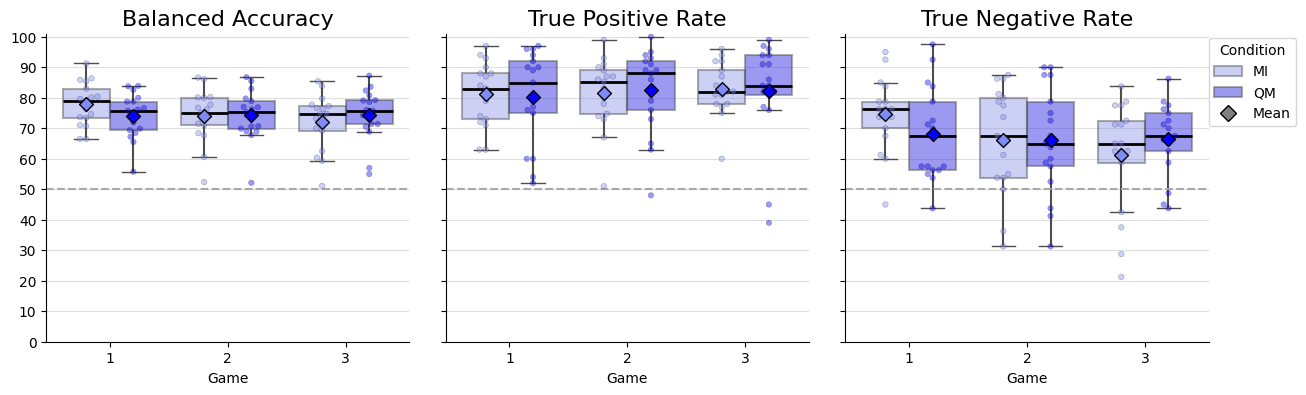

In [16]:
def plot_boxplot(df, metric, title, ax,  vlim=None, palette=None, legend_status=True):
    
    if palette is None:
        palette = sns.color_palette("Set2") 
    conditions = sorted(df["condition"].unique())
    n_cond = len(conditions)

    # boxplot
    sns.boxplot(
        data=df,
        x="n_game",
        y=metric,
        hue="condition",
        ax=ax,
        palette=palette,
        showcaps=True,
        boxprops={"alpha":0.45, "linewidth":1.5},
        whiskerprops={"linewidth": 1.5},
        medianprops={"color": "black", "linewidth": 2},
        showfliers=False,
        legend=legend_status
    )

    # swarm
    sns.swarmplot(
        data=df,
        x="n_game",
        y=metric,
        hue="condition",
        dodge=True,
        ax=ax,
        palette=palette,
        edgecolor="black", 
        linewidth=0.3,
        alpha=0.4,
        size=4,
        legend=False,
    )

    # средние значения
    means = (
        df.groupby(["n_game", "condition"])[metric]
        .mean()
        .reset_index()
    )

    x_levels = sorted(df["n_game"].unique())
    width = 0.4
    offsets = np.linspace(-width/2, width/2, n_cond)

    for i, cond in enumerate(conditions):
        sub = means[means["condition"] == cond]

        xs = [
            x_levels.index(x) + offsets[i]
            for x in sub["n_game"]
        ]

        ax.scatter(
            xs,
            sub[metric],
            marker="D",
            s=50,
            color=palette[i],
            edgecolor="black",
            zorder=5
        )

    ax.set_title(title, fontsize=16)
    if vlim is not None:
        ax.set_ylim(vlim)

    # аккуратная легенда   
    if legend_status:
        handles, labels = ax.get_legend_handles_labels()
        cond_handles = handles[:len(conditions)]
        cond_labels = ["MI", "QM"]#labels[:len(conditions)]

        # элемент для среднего
        mean_handle = Line2D(
            [0], [0],
            marker='D',
            color='w',
            markerfacecolor='gray',
            markeredgecolor='black',
            markersize=8,
            linestyle='None',
            label='Mean'
        )

        ax.legend(
            handles=cond_handles + [mean_handle],
            labels=cond_labels + ['Mean'],
            title="Condition",
            loc=[1, 0.7]
        )

palette = ["#7F8BF6FF", "#0400ff" ]
titles = ["Balanced Accuracy", "True Positive Rate", "True Negative Rate"]

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, metric in enumerate(["bal_acc", "TPR", "TNR"]):
    legend = True if i == 2 else False
    plot_boxplot(df_perf, metric, title=titles[i], vlim=(0, 101), ax=ax[i], palette=palette, legend_status=legend)
    ax[i].axhline(50, color="darkgrey", linestyle="--")
    ax[i].set_yticks(np.arange(0, 101, 10))
    ax[i].grid(alpha=.4, axis="y")
    sns.despine(ax=ax[i])
    ax[i].set_xlabel("Game")
    ax[i].set_ylabel("")
plt.subplots_adjust(wspace=0.1)  # расстояние по горизонтали
fig.savefig(r"../data/results/stat_graz/fig1.png", dpi=300, bbox_inches="tight")

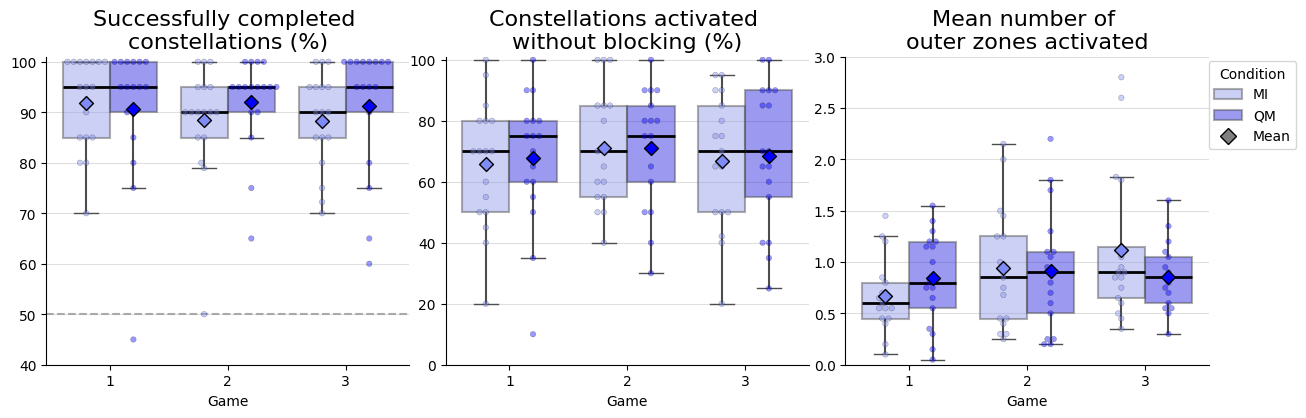

In [17]:
palette = ["#7F8BF6FF", "#0400ff" ]
titles = [
    "Successfully completed \nconstellations (%)",
    "Constellations activated \nwithout blocking (%)",
    "Mean number of \nouter zones activated"
]

vlims = [[40, 101], [0, 101], [0, 3]]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(["p_correct", "p_hh", "n_overkill_average"]):
    legend = True if i == 2 else False
    plot_boxplot(df_perf, metric, title=titles[i], vlim=vlims[i], ax=ax[i], palette=palette, legend_status=legend)
    # ax[i].axhline(50, color="darkgrey", linestyle="--")
    # ax[i].set_yticks(np.arange(0, 101, 10))
    ax[i].grid(alpha=.4, axis="y")
    sns.despine(ax=ax[i])
    ax[i].set_xlabel("Game")
    ax[i].set_ylabel("")
ax[0].axhline(50, color="darkgrey", linestyle="--")
plt.subplots_adjust(wspace=0.1)  # расстояние по горизонтали
fig.savefig(r"../data/results/stat_graz/fig2.png", dpi=300, bbox_inches="tight")

In [18]:
filename = r'..\data\results\questionario.xlsx'
df_surv = pd.read_excel(filename)
df_surv = pd.concat([df_surv.loc[df_surv.condition == 'MI'], df_surv.loc[df_surv.condition == 'QM']])
df_surv.head()

,subject,condition,n,attention,Difficulty,Success,TaskFit,TaskOrScreen,Auto
18,01TG,MI,1,0.646296,0.390741,0.772222,0.0,0.0,0.0
19,02ES,MI,1,0.896296,0.961111,0.953704,0.0,0.0,0.0
20,03AC,MI,1,0.744444,0.420370,0.877778,0.0,0.0,0.0
21,04AB,MI,1,0.518519,0.507407,0.905556,0.0,0.0,0.0
22,06KK,MI,1,0.670370,0.820370,0.805556,0.0,0.0,0.0


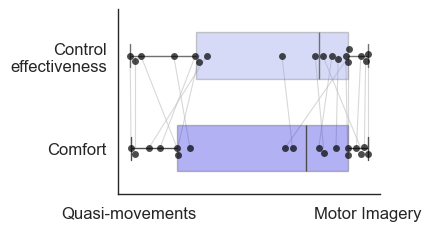

In [34]:
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

filename = r'..\data\results\questionario_final.xlsx'
df_surv_final = pd.read_excel(filename)
df_surv_final['x1'] = 0
df_surv_final['x2'] = 1


df_surv_final['y1'] = 0
df_surv_final['y2'] = 1

labels = ['Control\neffectiveness', 'Comfort']

fig, ax = plt.subplots(figsize=(4.2, 2.2), layout="constrained")

# линии между значениями одного участника
for _, row in df_surv_final.iterrows():
    ax.plot(
        [row["BetterPlay"], row["Comfort"]],
        [row["y1"], row["y2"]],
        color="0.75",
        linewidth=0.8,
        alpha=0.6,
        zorder=0
    )

# Performance
sns.boxplot(
    data=df_surv_final,
    y='y1',
    x='BetterPlay',
    whis=(0, 100),
    width=0.5,
    color=palette[0],
    ax=ax,
    orient='h',
    boxprops={"alpha":0.35},
    showfliers=False
)

sns.swarmplot(
    data=df_surv_final,
    y='y1',
    x='BetterPlay',
    color="black",
    alpha=.7,
    ax=ax,
    size=5,
    orient='h'
)

# Comfort
sns.boxplot(
    data=df_surv_final,
    y='y2',
    x='Comfort',
    whis=(0, 100),
    width=0.5,
    color=palette[1],
    ax=ax,
    orient='h',
    boxprops={"alpha":0.35},
    showfliers=False
)

sns.swarmplot(
    data=df_surv_final,
    y='y2',
    x='Comfort',
    color="black",
    alpha=.7,
    ax=ax,
    size=5,
    orient='h'
)


# подписи
ax.set_yticks([0, 1], labels, fontsize=12)
ax.set_xticks([0, 0.5, 1], ['Quasi-movements', '', 'Motor Imagery'], fontsize=12)

ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_title("Control Effectiveness", fontsize=14)

sns.despine(ax=ax)

filename = os.path.join(r'..\data\results\stat_graz\fig3.png')
fig.savefig(filename, dpi=300, bbox_inches='tight')

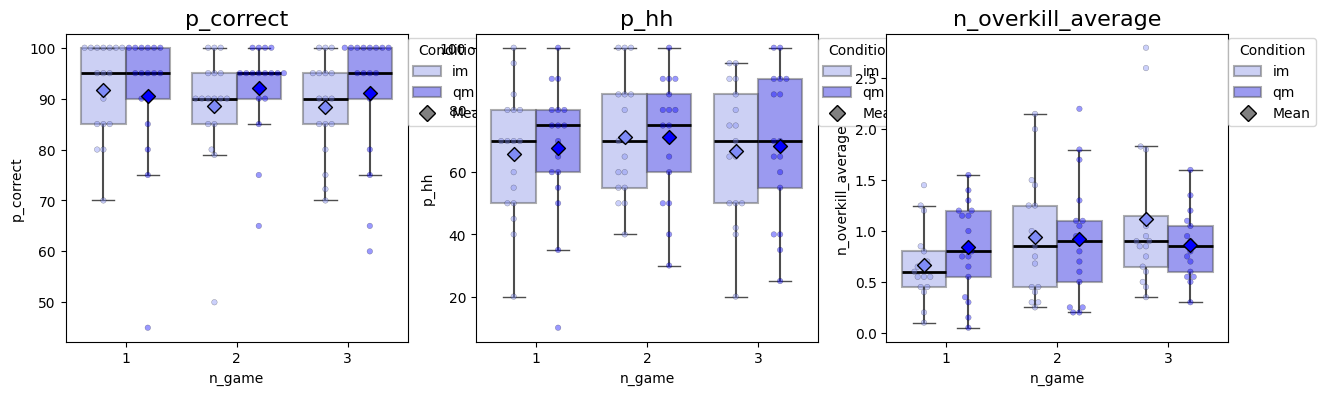

In [285]:
palette = ["#7F8BF6FF", "#0400ff" ]
fix, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(["p_correct", "p_hh", "n_overkill_average"]):
    plot_boxplot(df_perf, metric, title=metric, ax=ax[i], palette=palette)

In [212]:
df_perf

,subject,condition,n_game,TPR,TNR,bal_acc,p_correct,p_hh,n_overkill_average
0,01TG,im,1,84.0,76.25,80.12,95.0,95.0,0.55
1,01TG,im,2,89.0,61.25,75.12,85.0,85.0,1.00
2,01TG,im,3,83.0,62.50,72.75,95.0,90.0,0.90
3,01TG,qm,1,97.0,56.25,76.62,100.0,65.0,1.20
4,01TG,qm,2,86.0,87.50,86.75,95.0,90.0,0.25
...,...,...,...,...,...,...,...,...,...
97,25PP,im,2,67.0,78.75,72.88,90.0,85.0,0.45
98,25PP,im,3,82.0,71.25,76.62,85.0,75.0,0.85
99,25PP,qm,1,85.0,53.75,69.38,95.0,50.0,1.30
100,25PP,qm,2,89.0,65.00,77.00,100.0,40.0,0.90


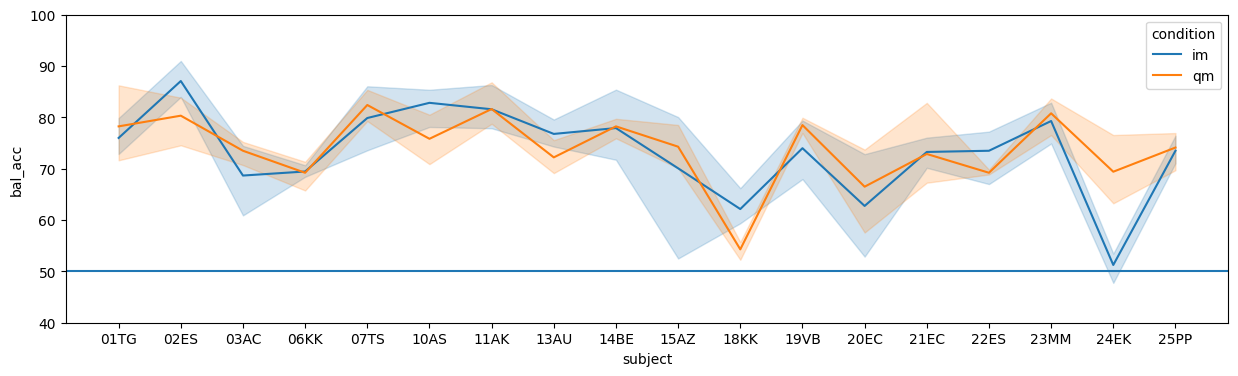

In [54]:
plt.figure(figsize=(15, 4))
metric = "bal_acc"
sns.lineplot(df_r2, x="subject", y=metric, hue="condition", estimator="mean", errorbar=("pi", 95))
plt.ylim(40, 100)
plt.axhline(50);

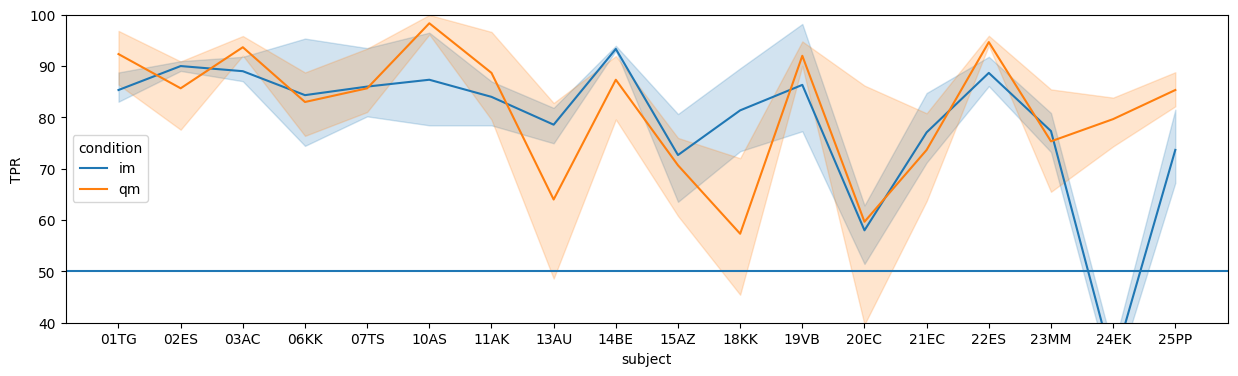

In [92]:
plt.figure(figsize=(15, 4))
metric = "TPR"
sns.lineplot(df_r2, x="subject", y=metric, hue="condition", estimator="mean", errorbar=("pi", 95))
plt.ylim(40, 100)
plt.axhline(50);

In [121]:
metric = "TPR"
dmetric = []
for s in df_r2.subject.unique():
    if s == "24EK":
        continue
    im = df_r2.loc[(df_r2.condition == "im") & (df_r2.subject == s)][metric].mean().round(2)
    qm = df_r2.loc[(df_r2.condition == "qm") & (df_r2.subject == s)][metric].mean().round(2)
    if (im < 50) or (qm < 50):
        print(f"{s}: im={im}, qm={qm}")
    dmetric.append([qm, im])
dm = np.array(dmetric)
mean_values = np.mean(dm, axis=0).round(2)
std_values = np.std(dm, axis=0).round(2)
f"IM: {mean_values[1]} +- {std_values[1]}; QM: {mean_values[0]} +- {std_values[0]}"

'IM: 81.94 +- 8.26; QM: 81.61 +- 12.25'

In [123]:
metric = "bal_acc"
dmetric = []
for s in df_r2.subject.unique():
    if s == "24EK":
        continue
    im = df_r2.loc[(df_r2.condition == "im") & (df_r2.subject == s)][metric].mean().round(2)
    qm = df_r2.loc[(df_r2.condition == "qm") & (df_r2.subject == s)][metric].mean().round(2)
    if (im < 50) or (qm < 50):
        print(f"{s}: im={im}, qm={qm}")
    dmetric.append([qm, im])
dm = np.array(dmetric)
mean_values = np.mean(dm, axis=0).round(2)
std_values = np.std(dm, axis=0).round(2)
f"IM: {mean_values[1]} +- {std_values[1]}; QM: {mean_values[0]} +- {std_values[0]}"

'IM: 74.63 +- 6.52; QM: 74.25 +- 6.73'

In [122]:
metric = "TNR"
dmetric = []
for s in df_r2.subject.unique():
    if s == "24EK":
        continue
    im = df_r2.loc[(df_r2.condition == "im") & (df_r2.subject == s)][metric].mean().round(2)
    qm = df_r2.loc[(df_r2.condition == "qm") & (df_r2.subject == s)][metric].mean().round(2)
    if (im < 50) or (qm < 50):
        print(f"{s}: im={im}, qm={qm}")
    dmetric.append([qm, im])
dm = np.array(dmetric)
mean_values = np.mean(dm, axis=0).round(2)
std_values = np.std(dm, axis=0).round(2)
f"IM: {mean_values[1]} +- {std_values[1]}; QM: {mean_values[0]} +- {std_values[0]}"

03AC: im=48.33, qm=53.33
18KK: im=42.92, qm=51.25
22ES: im=58.33, qm=43.75


'IM: 67.32 +- 11.21; QM: 66.89 +- 11.72'

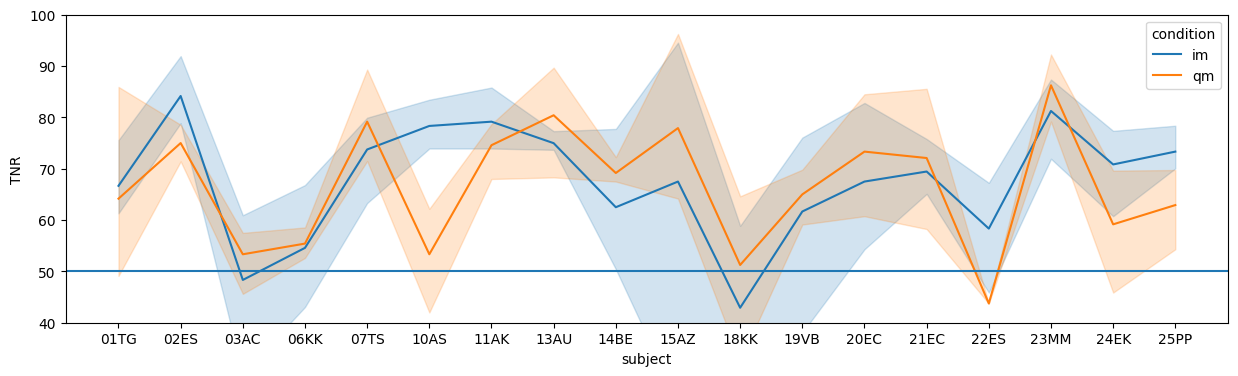

In [93]:
plt.figure(figsize=(15, 4))
metric = "TNR"
sns.lineplot(df_r2, x="subject", y=metric, hue="condition", estimator="mean", errorbar=("pi", 95))
plt.ylim(40, 100)
plt.axhline(50);

In [57]:
df_r2["prefer"] = "im"
metric = "kappa"
for s in df_r2.subject.unique():
    im_mean = df_r2.loc[(df_r2.subject == s) & (df_r2.condition == "im")][metric].mean()
    qm_mean = df_r2.loc[(df_r2.subject == s) & (df_r2.condition == "qm")][metric].mean()
    prefer = "im" if im_mean > qm_mean else "qm"
    df_r2.loc[df_r2.subject == s, "prefer"] = prefer
kappa_diff = df_r2.loc[df_r2.prefer == "im"][metric].mean() - df_r2.loc[df_r2.prefer == "qm"][metric].mean()

In [58]:
kappa_diff, df_r2.loc[df_r2.prefer == "im"][metric].mean(), df_r2.loc[df_r2.prefer == "qm"][metric].mean()

(np.float64(-0.02618055549053655),
 np.float64(0.4615765371373913),
 np.float64(0.4877570926279278))

<Axes: xlabel='subject', ylabel='kappa'>

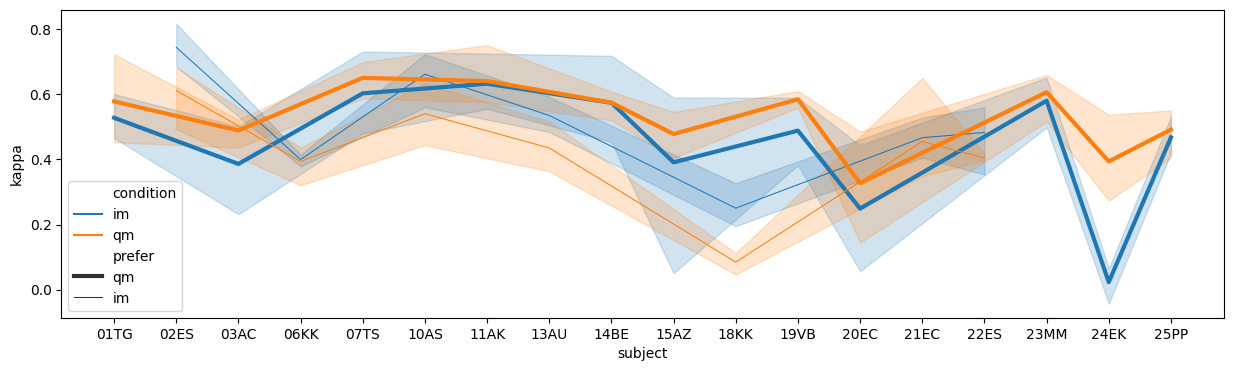

In [59]:
plt.figure(figsize=(15, 4))
sns.lineplot(df_r2, x="subject", y="kappa", hue="condition", size="prefer", estimator="mean", errorbar=("pi", 95))

In [ ]:
# без первого и 2-х последних поясов
# df_central = df_band.copy()

# df_central['label'] = 1
# df_central.loc[df_central.event_name.isin(TN), 'label'] = 0 

# df_game = []
# for subject in df_central.subject.unique():
#     for cond in ['im', 'qm']:
#         for n_game in df_central.loc[(df_central.subject == subject) & (df_central.condition == cond)]['n_game'].unique():
#             df_curr = df_central.loc[(df_central.subject == subject) & (df_central.condition == cond) & (df_central.n_game == n_game)]
#             n_success = 0
#             TNRs = []
#             for star in df_curr.n_star.unique():
#                 df_star = df_curr.loc[df_curr.n_star == star]
#                 correct = df_star.loc[((df_star.label == 1) & (df_star.decision == 1)) | ((df_star.label == 0) & (df_star.decision == 0))].shape[0]
#                 p_correct = round(correct / df_star.shape[0] * 100, 2)
#                 success = 1 if p_correct > 50 else 0
#                 n_success += success
#                 TNRs.append(df_star.loc[(df_star.label == 0) & (df_star.decision == 0)].shape[0] / df_star.loc[(df_star.label == 0)].shape[0])
#             df_game.append({
#                 'subject': subject, 
#                 'condition': cond, 
#                 'n_game': n_game, 
#                 'p_correct': round(n_success / df_curr.n_star.unique().shape[0] * 100, 2),
#                 'TNR': np.mean(TNRs)
#             })
# df_game = pd.DataFrame(df_game)

In [ ]:
# save2prizma(df_game, metric="p_correct")

In [ ]:
df_hh = []
for subject in df.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df.loc[(df.subject == subject) & (df.condition == cond)]['n_game'].unique():
            df_curr = df.loc[(df.subject == subject) & (df.condition == cond) & (df.n_game == n_game)]
            n_star = sum(df_curr.n_star.unique() != -1)
            n = 0
            for star in df_curr.n_star.unique():
                df_star = df_curr.loc[df_curr.n_star == star]
                if df_star.loc[df_star.event == 'start_holiday_home'].shape[0] == 0:
                    n += 1
            if n_star != 20:
                print(n_star)
            n_hh = df_curr.loc[df_curr.event == 'start_holiday_home'].shape[0]
            df_hh.append({
                'subject': subject, 
                'condition': cond, 
                'n_game': n_game, 
                'p_hh': round(n/n_star * 100, 2)
            })
df_hh = pd.DataFrame(df_hh)

10
10
10
10
19
10
10
10
10
10


In [64]:
save2prizma(df_hh, metric="p_hh")

<Axes: xlabel='subject', ylabel='p_hh'>

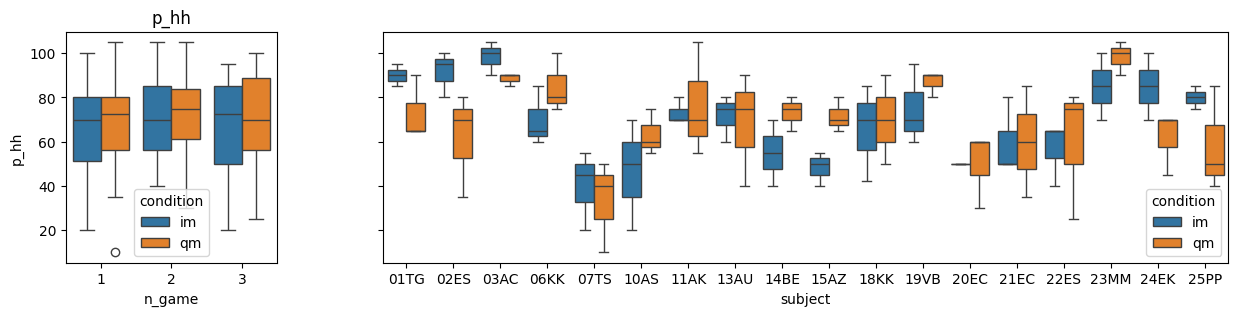

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(15, 3), sharey=True, width_ratios=[1, 4])
sns.boxplot(df_hh, x='n_game', y='p_hh', hue='condition', ax = ax[0])
ax[0].set_title("p_hh")
sns.boxplot(df_hh, x='subject', y='p_hh', hue='condition', ax = ax[1])

## averaged by condition

In [49]:
# без первого и 2-х последних поясов
df_central = df_band.copy()

TP = [f'inner_band_{i}' for i in range(2, 7)]
TN = [f'outer_band_{i}' for i in range(1, 5)]
df_central = df_central.loc[(df_central.event_name.isin(TP + TN))]

df_central['label'] = 1
df_central.loc[df_central.event_name.isin(TN), 'label'] = 0 

df_r2 = []
for subject in df_central.subject.unique():
    for cond in ['im', 'qm']:
        df_curr = df_central.loc[(df_central.subject == subject) & (df_central.condition == cond)]
        TPR = df_curr.loc[(df_curr.label == 1) & (df_curr.decision == 1)].shape[0] / df_curr.loc[df_curr.label == 1].shape[0]
        TNR = df_curr.loc[(df_curr.label == 0) & (df_curr.decision == 0)].shape[0] / df_curr.loc[df_curr.label == 0].shape[0]

        n_success = 0
        TNRs = []
        for star in df_curr.n_star.unique():
            df_star = df_curr.loc[df_curr.n_star == star]
            correct = df_star.loc[((df_star.label == 1) & (df_star.decision == 1)) | ((df_star.label == 0) & (df_star.decision == 0))].shape[0]
            p_correct = round(correct / df_star.shape[0] * 100, 2)
            success = 1 if p_correct > 50 else 0
            n_success += success
            TNRs.append(df_star.loc[(df_star.label == 0) & (df_star.decision == 0)].shape[0] / df_star.loc[(df_star.label == 0)].shape[0])
        
        df_r2.append({
            'subject': subject, 
            'condition': cond, 
            'r2': r2_score(df_curr.label.values, df_curr.decision.values),
            'kappa': cohen_kappa_score(df_curr.label.values, df_curr.decision.values),
            'TPR': round(TPR * 100, 2),
            'TNR': round(TNR * 100, 2),
            'p_correct': round(n_success / df_curr.n_star.unique().shape[0] * 100, 2),
        })
df_r2 = pd.DataFrame(df_r2)

In [ ]:


save2prizma_xy(df_r2, metric="p_correct")

In [67]:
df_hh = []
for subject in df.subject.unique():
    for cond in ['im', 'qm']:
        df_curr = df.loc[(df.subject == subject) & (df.condition == cond)]
        n_star = sum(df_curr.n_star.unique() != -1)
        n = 0
        for star in df_curr.n_star.unique():
            df_star = df_curr.loc[df_curr.n_star == star]
            if df_star.loc[df_star.event == 'start_holiday_home'].shape[0] == 0:
                n += 1
        n_hh = df_curr.loc[df_curr.event == 'start_holiday_home'].shape[0]
        df_hh.append({
            'subject': subject, 
            'condition': cond, 
            'p_hh': round(n/n_star * 100, 2)
        })
df_hh = pd.DataFrame(df_hh)

In [72]:
from scipy.stats import wilcoxon

In [70]:
save2prizma_xy(df_hh, metric="p_hh")

In [94]:
filename = r'..\data\results\game_metrics_per_condition.csv'
df_outer = pd.read_csv(filename)
df_outer = df_outer.loc[~df_outer.subject.isin(['04AB', '24EK'])]

In [88]:
save2prizma_xy(df_outer, metric="n_overkill_average")

Text(0.5, 1.0, 'n_overkill_average')

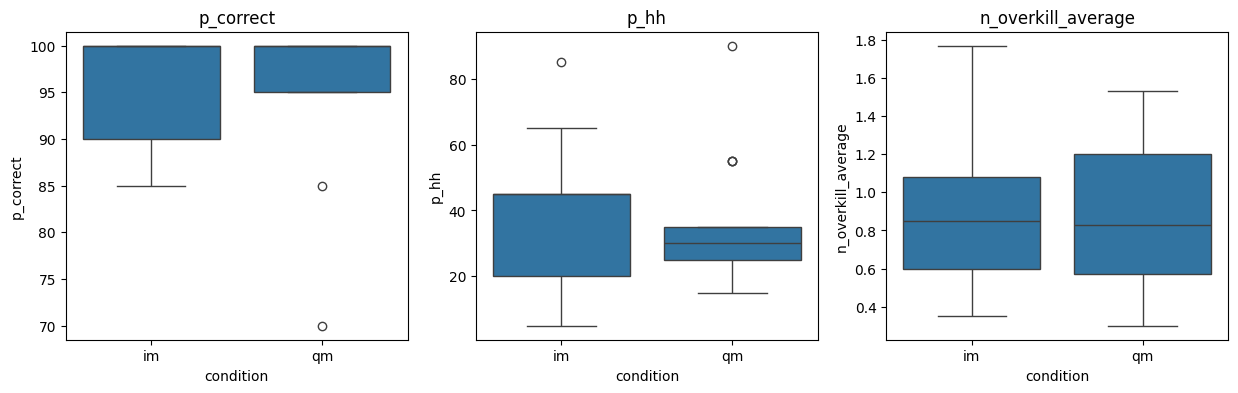

In [90]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(df_r2, x='condition', y='p_correct', ax=ax[0])
sns.boxplot(df_hh, x='condition', y='p_hh', ax=ax[1])
sns.boxplot(df_outer, x='condition', y='n_overkill_average', ax=ax[2])
ax[0].set_title("p_correct")
ax[1].set_title("p_hh")
ax[2].set_title("n_overkill_average")

In [93]:
def calc_wilcoxon(df, metric):
    values1 = df.loc[df.condition == "im"][metric].values 
    values2 = df.loc[df.condition == "qm"][metric].values
    test = wilcoxon(values1, values2, zero_method="pratt")
    # print(values1, values2)
    return f"W(17)={test[0]:.0f}, p={test[1]:.2f}"

print("p_correct", calc_wilcoxon(df_r2, "p_correct"))
print("p_hh", calc_wilcoxon(df_hh, "p_hh"))
print("n_overkill_average", calc_wilcoxon(df_outer, "n_overkill_average"))

p_correct W(17)=42, p=0.71
p_hh W(17)=70, p=0.87
n_overkill_average W(17)=62, p=0.52


In [66]:
filename = r'..\data\results\game_metrics_per_n_game.csv'
df_outer = pd.read_csv(filename)
df_outer = df_outer.loc[~df_outer.subject.isin(['04AB'])]

In [67]:
df_outer

,total_score,game_duration,p_green_bands,aver_time,green_steps_min,band_gain_min,n_stars,points_per_star,n_hh_average,n_overkill_average,condition,n_game,subject
0,3873,4.95,84.55,9.85,40.51,25.89,20,193.65,0.10,0.55,im,1,01TG
1,3443,5.45,85.84,11.20,37.23,23.04,20,172.15,0.20,1.00,im,2,01TG
2,3138,5.53,81.98,11.40,33.16,16.84,20,156.90,0.25,0.90,im,3,01TG
3,3993,7.92,96.55,17.15,26.76,18.72,20,199.65,0.90,1.20,qm,1,01TG
4,3738,5.13,84.68,10.40,37.21,23.65,20,186.90,0.20,0.25,qm,2,01TG
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,2139,7.72,66.96,10.65,30.99,10.99,20,106.95,0.20,0.45,im,2,25PP
109,3360,6.97,80.70,12.25,31.84,17.39,20,168.00,0.35,0.85,im,3,25PP
110,3050,7.65,85.85,15.45,25.24,13.79,20,152.50,0.75,1.30,qm,1,25PP
111,4062,6.33,88.29,13.00,32.77,22.15,20,203.10,0.45,0.90,qm,2,25PP


<Axes: xlabel='subject', ylabel='n_overkill_average'>

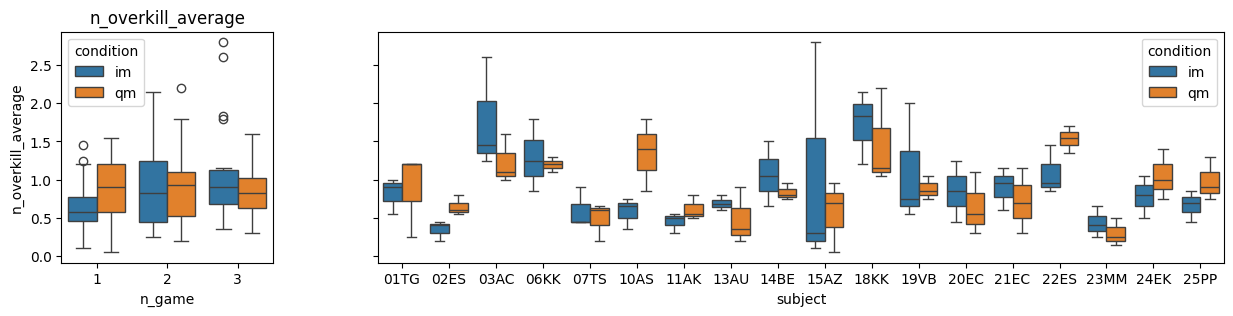

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(15, 3), sharey=True, width_ratios=[1, 4])
sns.boxplot(df_outer, x='n_game', y='n_overkill_average', hue='condition', ax = ax[0])
ax[0].set_title("n_overkill_average")
sns.boxplot(df_outer, x='subject', y='n_overkill_average', hue='condition', ax = ax[1])

In [69]:
save2prizma(df_outer, metric="n_overkill_average")

# Final Plots

In [ ]:
metric = "TPR"
dmetric = []
for s in df_r2.subject.unique():
    im = df_r2.loc[(df_r2.condition == "im") & (df_r2.subject == s)][metric].mean().round(2)
    qm = df_r2.loc[(df_r2.condition == "qm") & (df_r2.subject == s)][metric].mean().round(2)
    # if (im > 70) or (qm > 70):
    #     print(f"{s}: im={im}, qm={qm}")
    dmetric.append([qm, im])
dm = np.array(dmetric)
np.mean(dm, axis=0)

array([81.50055556, 79.15      ])

In [100]:
n_qm = np.where(dm[:, 0] > 50)[0].shape[0]
n_im = np.where(dm[:, 1] > 50)[0].shape[0]
n_qm, n_im

(18, 17)

In [ ]:
n_qm = np.where(np.diff(dm, axis=1) > 0)[0].shape[0]

In [90]:
n_qm, n_im, dm.shape[0]

(7, 1, 18)